# TP2 - Filtrage collaboratif

**Master Sciences des Données - Université Abdelmalek Essaâdi, ENS Tétouan**  
**Jeu de données : MovieLens 100K**

Notebook complété : matrice d'interactions, densité, cosinus, premières
prédictions, top-k, influence de $k$, débiaisage, films similaires et Pearson.
Dans Colab, sélectionner **Exécution > Tout exécuter**. Le téléchargement
bascule automatiquement vers un miroir de secours si GroupLens ne répond pas.

In [1]:
"""Outils pédagogiques pour les TP MovieLens.

Le module privilégie des implémentations explicites, reproductibles et proches
des formules des sujets. Les zéros représentent exclusivement des notes
manquantes ; les moyennes sont donc calculées sur les valeurs observées.
"""

from __future__ import annotations

import os
import shutil
import time
import urllib.request
import zipfile
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, pairwise_distances


SEED = 42
EPS = 1e-12


def _download_file(url: str, destination: Path, timeout: int = 45) -> None:
    """Télécharge un fichier avec un délai borné et un User-Agent explicite."""
    destination.parent.mkdir(parents=True, exist_ok=True)
    request = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0 TP-MovieLens/1.0"})
    temporary = destination.with_suffix(destination.suffix + ".part")
    try:
        with urllib.request.urlopen(request, timeout=timeout) as response, temporary.open("wb") as stream:
            shutil.copyfileobj(response, stream)
        temporary.replace(destination)
    finally:
        if temporary.exists():
            temporary.unlink()


def _download_and_extract(url: str, archive_path: Path, target_parent: Path) -> None:
    """Télécharge puis extrait une archive MovieLens avec trois tentatives."""
    target_parent.mkdir(parents=True, exist_ok=True)
    last_error: Exception | None = None
    for attempt in range(1, 4):
        try:
            if not archive_path.exists():
                print(f"Téléchargement GroupLens (tentative {attempt}/3)…")
                _download_file(url, archive_path)
            with zipfile.ZipFile(archive_path) as archive:
                archive.extractall(target_parent)
            return
        except Exception as exc:
            last_error = exc
            archive_path.unlink(missing_ok=True)
            if attempt < 3:
                time.sleep(attempt)
    raise RuntimeError(f"Téléchargement GroupLens impossible : {last_error}") from last_error


def _download_fallback_files(folder: Path, files: dict[str, str]) -> None:
    """Récupère les seuls fichiers nécessaires depuis un miroir GitHub public."""
    print("Source GroupLens momentanément indisponible : utilisation du miroir de secours…")
    folder.mkdir(parents=True, exist_ok=True)
    for filename, url in files.items():
        destination = folder / filename
        if not destination.exists():
            print(f"  - {filename}")
            _download_file(url, destination)


def ensure_ml_latest_small() -> Path:
    """Retourne le dossier ml-latest-small, localement ou dans Colab."""
    override = os.environ.get("ML_LATEST_SMALL_DIR")
    if override and (Path(override) / "ratings.csv").exists():
        return Path(override)
    root = Path("/content/data") if Path("/content").exists() else Path("data")
    folder = root / "ml-latest-small"
    if not (folder / "ratings.csv").exists():
        try:
            _download_and_extract(
                "https://files.grouplens.org/datasets/movielens/ml-latest-small.zip",
                root / "ml-latest-small.zip",
                root,
            )
        except RuntimeError:
            _download_fallback_files(
                folder,
                {
                    "ratings.csv": "https://raw.githubusercontent.com/alura-cursos/introducao-a-data-science/master/aula0/ml-latest-small/ratings.csv",
                    "movies.csv": "https://raw.githubusercontent.com/alura-cursos/introducao-a-data-science/master/aula0/ml-latest-small/movies.csv",
                },
            )
    if not all((folder / name).exists() for name in ("ratings.csv", "movies.csv")):
        raise FileNotFoundError("MovieLens Latest Small incomplet après téléchargement")
    return folder


def ensure_ml100k() -> Path:
    """Retourne le dossier ml-100k, localement ou dans Colab."""
    override = os.environ.get("ML_100K_DIR")
    if override and (Path(override) / "u.data").exists():
        return Path(override)
    root = Path("/content/data") if Path("/content").exists() else Path("data")
    folder = root / "ml-100k"
    if not (folder / "u.data").exists():
        try:
            _download_and_extract(
                "https://files.grouplens.org/datasets/movielens/ml-100k.zip",
                root / "ml-100k.zip",
                root,
            )
        except RuntimeError:
            _download_fallback_files(
                folder,
                {
                    "u.data": "https://raw.githubusercontent.com/tiepvupsu/ebookML_src/master/src/NBCF/ml-100k/u.data",
                    "u.item": "https://raw.githubusercontent.com/tiepvupsu/ebookML_src/master/src/NBCF/ml-100k/u.item",
                },
            )
    if not all((folder / name).exists() for name in ("u.data", "u.item")):
        raise FileNotFoundError("MovieLens 100K incomplet après téléchargement")
    return folder


def build_utility_matrix(
    frame: pd.DataFrame,
    user_col: str,
    item_col: str,
    rating_col: str,
    users: np.ndarray | None = None,
    items: np.ndarray | None = None,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, dict, dict]:
    """Construit une matrice utilisateur-item et les deux mappings d'indices."""
    users = np.sort(frame[user_col].unique()) if users is None else np.asarray(users)
    items = np.sort(frame[item_col].unique()) if items is None else np.asarray(items)
    user_to_idx = {value: idx for idx, value in enumerate(users)}
    item_to_idx = {value: idx for idx, value in enumerate(items)}
    utility = np.zeros((len(users), len(items)), dtype=np.float32)
    u_idx = frame[user_col].map(user_to_idx).to_numpy()
    i_idx = frame[item_col].map(item_to_idx).to_numpy()
    utility[u_idx, i_idx] = frame[rating_col].to_numpy(dtype=np.float32)
    return utility, users, items, user_to_idx, item_to_idx


def dataframe_to_triplets(
    frame: pd.DataFrame,
    user_to_idx: dict,
    item_to_idx: dict,
    user_col: str,
    item_col: str,
    rating_col: str,
) -> np.ndarray:
    """Convertit un dataframe en tableau (index_user, index_item, note)."""
    return np.column_stack(
        [
            frame[user_col].map(user_to_idx).to_numpy(dtype=np.int32),
            frame[item_col].map(item_to_idx).to_numpy(dtype=np.int32),
            frame[rating_col].to_numpy(dtype=np.float32),
        ]
    )


def load_latest_small(
    data_dir: Path,
    train_fraction: float = 0.80,
    seed: int = SEED,
) -> dict:
    """Charge MovieLens Latest Small et applique le split global demandé."""
    ratings = pd.read_csv(Path(data_dir) / "ratings.csv")
    movies = pd.read_csv(Path(data_dir) / "movies.csv")
    users = np.sort(ratings.userId.unique())
    items = np.sort(ratings.movieId.unique())
    shuffled = ratings.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    split = int(len(shuffled) * train_fraction)
    train_df = shuffled.iloc[:split].copy()
    test_df = shuffled.iloc[split:].copy()
    utility, users, items, user_to_idx, item_to_idx = build_utility_matrix(
        train_df, "userId", "movieId", "rating", users=users, items=items
    )
    test_set = dataframe_to_triplets(
        test_df, user_to_idx, item_to_idx, "userId", "movieId", "rating"
    )
    return {
        "ratings": ratings,
        "movies": movies,
        "train_df": train_df,
        "test_df": test_df,
        "utility": utility,
        "mask": utility != 0,
        "test_set": test_set,
        "users": users,
        "items": items,
        "user_to_idx": user_to_idx,
        "item_to_idx": item_to_idx,
    }


def load_ml100k(data_dir: Path) -> dict:
    """Charge MovieLens 100K et construit la matrice complète."""
    columns = ["user_id", "item_id", "rating", "timestamp"]
    ratings = pd.read_csv(Path(data_dir) / "u.data", sep="\t", names=columns)
    utility, users, items, user_to_idx, item_to_idx = build_utility_matrix(
        ratings, "user_id", "item_id", "rating"
    )
    item_columns = [
        "movie_id", "movie_title", "release_date", "video_release_date", "IMDb_URL",
        "unknown", "Action", "Adventure", "Animation", "Children", "Comedy", "Crime",
        "Documentary", "Drama", "Fantasy", "Film-Noir", "Horror", "Musical", "Mystery",
        "Romance", "Sci-Fi", "Thriller", "War", "Western",
    ]
    movies = pd.read_csv(
        Path(data_dir) / "u.item",
        sep="|",
        names=item_columns,
        encoding="latin-1",
    )
    return {
        "ratings": ratings,
        "movies": movies,
        "utility": utility,
        "users": users,
        "items": items,
        "user_to_idx": user_to_idx,
        "item_to_idx": item_to_idx,
    }


def observed_means(matrix: np.ndarray, axis: int) -> np.ndarray:
    """Moyenne par ligne/colonne en ignorant les zéros manquants."""
    mask = matrix != 0
    sums = matrix.sum(axis=axis, dtype=np.float64)
    counts = mask.sum(axis=axis)
    global_mean = float(matrix[mask].mean()) if np.any(mask) else 0.0
    return np.divide(
        sums,
        counts,
        out=np.full_like(sums, global_mean, dtype=np.float64),
        where=counts > 0,
    ).astype(np.float32)


def center_observed(matrix: np.ndarray, axis: int = 1) -> tuple[np.ndarray, np.ndarray]:
    """Centre uniquement les notes observées et préserve les zéros manquants."""
    mask = matrix != 0
    means = observed_means(matrix, axis=axis)
    if axis == 1:
        centered = np.where(mask, matrix - means[:, None], 0.0)
    else:
        centered = np.where(mask, matrix - means[None, :], 0.0)
    return centered.astype(np.float32), means


def get_similarities(utility: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Produits scalaires users/items et inverses de normes, sans boucle."""
    matrix = np.asarray(utility, dtype=np.float32)
    user_products = matrix @ matrix.T
    item_products = matrix.T @ matrix
    user_norms = np.sqrt(np.clip(np.diag(user_products), 0, None))
    item_norms = np.sqrt(np.clip(np.diag(item_products), 0, None))
    inv_user_norm = np.divide(
        1.0, user_norms, out=np.zeros_like(user_norms), where=user_norms > EPS
    )
    inv_item_norm = np.divide(
        1.0, item_norms, out=np.zeros_like(item_norms), where=item_norms > EPS
    )
    return user_products, item_products, inv_user_norm, inv_item_norm


def cosine_from_products(products: np.ndarray, inv_norm: np.ndarray) -> np.ndarray:
    """Transforme une matrice de produits scalaires en similarités cosinus."""
    return (products * inv_norm[:, None] * inv_norm[None, :]).astype(np.float32)


def rank_users(id_user: int, similarities: np.ndarray, inv_norm: np.ndarray) -> list[tuple[int, float]]:
    scores = similarities[id_user] * inv_norm[id_user] * inv_norm
    order = np.argsort(scores)[::-1]
    return [(int(idx), float(scores[idx])) for idx in order if idx != id_user]


def rank_items(id_movie: int, similarities: np.ndarray, inv_norm: np.ndarray) -> list[tuple[int, float]]:
    scores = similarities[id_movie] * inv_norm[id_movie] * inv_norm
    order = np.argsort(scores)[::-1]
    return [(int(idx), float(scores[idx])) for idx in order if idx != id_movie]


def _weighted_average(values: np.ndarray, weights: np.ndarray, fallback: float) -> float:
    denominator = float(np.abs(weights).sum())
    if denominator <= EPS:
        return float(fallback)
    return float(np.dot(weights, values) / denominator)


def recommend_user_based_item(
    id_user: int,
    id_item: int,
    utility: np.ndarray,
    similarities: np.ndarray,
    inv_norm: np.ndarray,
    k: int = 10,
    mask: np.ndarray | None = None,
    baseline: float = 0.0,
) -> float:
    """Prédit une note via les k utilisateurs les plus proches ayant noté l'item."""
    mask = utility != 0 if mask is None else mask
    scores = similarities[id_user] * inv_norm[id_user] * inv_norm
    candidates = np.flatnonzero(mask[:, id_item])
    candidates = candidates[candidates != id_user]
    if candidates.size == 0:
        return float(baseline)
    order = candidates[np.argsort(scores[candidates])[::-1][:k]]
    return _weighted_average(utility[order, id_item], scores[order], baseline)


def recommend_item_based_item(
    id_user: int,
    id_item: int,
    utility: np.ndarray,
    similarities: np.ndarray,
    inv_norm: np.ndarray,
    k: int = 10,
    mask: np.ndarray | None = None,
    baseline: float = 0.0,
) -> float:
    """Prédit une note via les k items les plus proches déjà notés."""
    mask = utility != 0 if mask is None else mask
    scores = similarities[id_item] * inv_norm[id_item] * inv_norm
    candidates = np.flatnonzero(mask[id_user])
    candidates = candidates[candidates != id_item]
    if candidates.size == 0:
        return float(baseline)
    order = candidates[np.argsort(scores[candidates])[::-1][:k]]
    return _weighted_average(utility[id_user, order], scores[order], baseline)


def precompute_topk(
    products: np.ndarray,
    inv_norm: np.ndarray,
    k: int,
    block_size: int = 512,
) -> tuple[np.ndarray, np.ndarray]:
    """Pré-calcul des k voisins cosinus par blocs, sans dupliquer toute la matrice."""
    n = products.shape[0]
    k = min(k, max(1, n - 1))
    indices = np.empty((n, k), dtype=np.int32)
    weights = np.empty((n, k), dtype=np.float32)
    for start in range(0, n, block_size):
        stop = min(n, start + block_size)
        scores = products[start:stop] * inv_norm[start:stop, None] * inv_norm[None, :]
        rows = np.arange(stop - start)
        scores[rows, np.arange(start, stop)] = -np.inf
        part = np.argpartition(scores, -k, axis=1)[:, -k:]
        part_scores = np.take_along_axis(scores, part, axis=1)
        order = np.argsort(part_scores, axis=1)[:, ::-1]
        indices[start:stop] = np.take_along_axis(part, order, axis=1)
        weights[start:stop] = np.take_along_axis(part_scores, order, axis=1)
    return indices, weights


def predict_user_topk_matrix(
    utility: np.ndarray,
    mask: np.ndarray,
    neighbor_indices: np.ndarray,
    neighbor_weights: np.ndarray,
    baselines: np.ndarray | None = None,
) -> np.ndarray:
    """Matrice complète des prédictions user-based avec dénominateur observé."""
    predictions = np.empty_like(utility, dtype=np.float32)
    for user in range(utility.shape[0]):
        idx = neighbor_indices[user]
        weights = neighbor_weights[user][:, None]
        values = utility[idx]
        observed = mask[idx]
        numerator = (weights * values).sum(axis=0)
        denominator = (np.abs(weights) * observed).sum(axis=0)
        row = np.divide(
            numerator,
            denominator,
            out=np.zeros_like(numerator, dtype=np.float32),
            where=denominator > EPS,
        )
        if baselines is not None:
            row += baselines[user]
        predictions[user] = row
    return predictions


def predict_item_topk_matrix(
    utility: np.ndarray,
    mask: np.ndarray,
    neighbor_indices: np.ndarray,
    neighbor_weights: np.ndarray,
    baselines: np.ndarray | None = None,
) -> np.ndarray:
    """Matrice complète des prédictions item-based avec dénominateur observé."""
    predictions = np.empty_like(utility, dtype=np.float32)
    for user in range(utility.shape[0]):
        values = utility[user, neighbor_indices]
        observed = mask[user, neighbor_indices]
        numerator = (neighbor_weights * values).sum(axis=1)
        denominator = (np.abs(neighbor_weights) * observed).sum(axis=1)
        row = np.divide(
            numerator,
            denominator,
            out=np.zeros_like(numerator, dtype=np.float32),
            where=denominator > EPS,
        )
        if baselines is not None:
            row += baselines[user]
        predictions[user] = row
    return predictions


def rmse_from_matrix(test_set: np.ndarray, predictions: np.ndarray) -> float:
    users = test_set[:, 0].astype(np.int32)
    items = test_set[:, 1].astype(np.int32)
    actual = test_set[:, 2].astype(np.float32)
    pred = np.clip(predictions[users, items], 0.5, 5.0)
    return float(np.sqrt(mean_squared_error(actual, pred)))


def get_rmse_user_based(
    test_set: np.ndarray,
    utility: np.ndarray,
    similarities: np.ndarray,
    inv_norm: np.ndarray,
    k: int = 10,
    mask: np.ndarray | None = None,
    baselines: np.ndarray | None = None,
) -> float:
    """RMSE demandée pour l'approche orientée utilisateurs."""
    mask = utility != 0 if mask is None else mask
    values = []
    for user, item, _ in test_set:
        user, item = int(user), int(item)
        baseline = 0.0 if baselines is None else float(baselines[user])
        values.append(
            recommend_user_based_item(
                user, item, utility, similarities, inv_norm, k, mask, baseline
            )
        )
    pred = np.clip(np.asarray(values), 0.5, 5.0)
    return float(np.sqrt(mean_squared_error(test_set[:, 2], pred)))


def get_rmse_item_based(
    test_set: np.ndarray,
    utility: np.ndarray,
    similarities: np.ndarray,
    inv_norm: np.ndarray,
    k: int = 10,
    mask: np.ndarray | None = None,
    baselines: np.ndarray | None = None,
) -> float:
    """RMSE demandée pour l'approche orientée items."""
    mask = utility != 0 if mask is None else mask
    values = []
    for user, item, _ in test_set:
        user, item = int(user), int(item)
        baseline = 0.0 if baselines is None else float(baselines[user])
        values.append(
            recommend_item_based_item(
                user, item, utility, similarities, inv_norm, k, mask, baseline
            )
        )
    pred = np.clip(np.asarray(values), 0.5, 5.0)
    return float(np.sqrt(mean_squared_error(test_set[:, 2], pred)))


def ndcg_at_k_from_matrix(
    test_set: np.ndarray,
    predictions: np.ndarray,
    train_mask: np.ndarray,
    k: int = 10,
) -> float:
    """NDCG@k moyen ; les items d'entraînement sont exclus du classement."""
    by_user: dict[int, dict[int, float]] = defaultdict(dict)
    for user, item, rating in test_set:
        by_user[int(user)][int(item)] = float(rating)
    values = []
    for user, relevant in by_user.items():
        scores = predictions[user].astype(np.float64, copy=True)
        scores[train_mask[user]] = -np.inf
        width = min(k, np.isfinite(scores).sum())
        if width == 0:
            continue
        top = np.argpartition(scores, -width)[-width:]
        top = top[np.argsort(scores[top])[::-1]]
        relevance = np.array([relevant.get(int(item), 0.0) for item in top])
        discounts = np.log2(np.arange(2, width + 2))
        dcg = float(np.sum((np.power(2.0, relevance) - 1.0) / discounts))
        ideal_rel = np.sort(np.fromiter(relevant.values(), dtype=float))[::-1][:width]
        ideal_discounts = np.log2(np.arange(2, len(ideal_rel) + 2))
        idcg = float(np.sum((np.power(2.0, ideal_rel) - 1.0) / ideal_discounts))
        if idcg > 0:
            values.append(dcg / idcg)
    return float(np.mean(values))


def get_ndcg_at_k_user_based(
    test_set: np.ndarray,
    utility: np.ndarray,
    similarities: np.ndarray,
    inv_norm: np.ndarray,
    k: int = 10,
    k_ndcg: int = 10,
    mask: np.ndarray | None = None,
    baselines: np.ndarray | None = None,
) -> float:
    mask = utility != 0 if mask is None else mask
    idx, weights = precompute_topk(similarities, inv_norm, k)
    pred = predict_user_topk_matrix(utility, mask, idx, weights, baselines)
    return ndcg_at_k_from_matrix(test_set, pred, mask, k_ndcg)


def get_ndcg_at_k_item_based(
    test_set: np.ndarray,
    utility: np.ndarray,
    similarities: np.ndarray,
    inv_norm: np.ndarray,
    k: int = 10,
    k_ndcg: int = 10,
    mask: np.ndarray | None = None,
    baselines: np.ndarray | None = None,
) -> float:
    mask = utility != 0 if mask is None else mask
    idx, weights = precompute_topk(similarities, inv_norm, k)
    pred = predict_item_topk_matrix(utility, mask, idx, weights, baselines)
    return ndcg_at_k_from_matrix(test_set, pred, mask, k_ndcg)


def svd_decompose(utility: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """SVD NumPy réduite ; la troncature au rang N est faite ensuite."""
    return np.linalg.svd(utility.astype(np.float32), full_matrices=False)


def svd_predict(
    components: tuple[np.ndarray, np.ndarray, np.ndarray],
    rank: int,
    baselines: np.ndarray | None = None,
) -> np.ndarray:
    u, singular_values, vt = components
    rank = min(rank, len(singular_values))
    pred = (u[:, :rank] * singular_values[:rank]) @ vt[:rank]
    if baselines is not None:
        pred = pred + baselines[:, None]
    return pred.astype(np.float32)


def get_rmse_svd(
    test_set: np.ndarray,
    utility: np.ndarray,
    N: int = 100,
    baselines: np.ndarray | None = None,
    components: tuple[np.ndarray, np.ndarray, np.ndarray] | None = None,
) -> float:
    components = svd_decompose(utility) if components is None else components
    return rmse_from_matrix(test_set, svd_predict(components, N, baselines))


def get_ndcg_svd(
    test_set: np.ndarray,
    utility: np.ndarray,
    k_ndcg: int = 10,
    N: int = 100,
    baselines: np.ndarray | None = None,
    mask: np.ndarray | None = None,
    components: tuple[np.ndarray, np.ndarray, np.ndarray] | None = None,
) -> float:
    mask = utility != 0 if mask is None else mask
    components = svd_decompose(utility) if components is None else components
    pred = svd_predict(components, N, baselines)
    return ndcg_at_k_from_matrix(test_set, pred, mask, k_ndcg)


def train_test_split_per_user(
    ratings: np.ndarray,
    n_test: int = 10,
    seed: int = SEED,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Retire n_test notes par utilisateur, de manière déterministe."""
    rng = np.random.default_rng(seed)
    train = ratings.copy()
    test = np.zeros_like(ratings)
    triplets = []
    for user in range(ratings.shape[0]):
        observed = np.flatnonzero(ratings[user])
        chosen = rng.choice(observed, size=min(n_test, len(observed)), replace=False)
        test[user, chosen] = ratings[user, chosen]
        train[user, chosen] = 0.0
        triplets.extend((user, int(item), float(ratings[user, item])) for item in chosen)
    assert not np.any((train != 0) & (test != 0))
    return train, test, np.asarray(triplets, dtype=np.float32)


def fast_similarity(ratings: np.ndarray, kind: str = "user") -> np.ndarray:
    """Similarité cosinus vectorisée pour le TP2."""
    vectors = ratings if kind == "user" else ratings.T
    products = vectors @ vectors.T
    norms = np.sqrt(np.clip(np.diag(products), 0, None))
    inv = np.divide(1.0, norms, out=np.zeros_like(norms), where=norms > EPS)
    return (products * inv[:, None] * inv[None, :]).astype(np.float32)


def predict_fast_simple(ratings: np.ndarray, similarity: np.ndarray, kind: str = "user") -> np.ndarray:
    """Version matricielle de la première prédiction naïve du TP2."""
    denominator = np.abs(similarity).sum(axis=1)
    if kind == "user":
        pred = similarity @ ratings
        return np.divide(
            pred,
            denominator[:, None],
            out=np.zeros_like(pred),
            where=denominator[:, None] > EPS,
        )
    pred = ratings @ similarity
    return np.divide(
        pred,
        denominator[None, :],
        out=np.zeros_like(pred),
        where=denominator[None, :] > EPS,
    )


def mse_on_observed(pred: np.ndarray, actual: np.ndarray) -> float:
    mask = actual != 0
    return float(mean_squared_error(actual[mask], np.clip(pred[mask], 0.5, 5.0)))


def rmse_on_observed(pred: np.ndarray, actual: np.ndarray) -> float:
    return float(np.sqrt(mse_on_observed(pred, actual)))


def top_k_movies(
    similarity: np.ndarray,
    titles: dict[int, str],
    movie_idx: int,
    k: int = 6,
) -> list[str]:
    order = np.argsort(similarity[movie_idx])[::-1]
    order = [int(idx) for idx in order if idx != movie_idx][:k]
    return [titles[idx] for idx in order]


def pearson_item_similarity(train: np.ndarray) -> np.ndarray:
    similarity = 1.0 - pairwise_distances(train.T, metric="correlation")
    similarity = np.nan_to_num(similarity, nan=0.0, posinf=0.0, neginf=0.0)
    return similarity.astype(np.float32)

In [2]:
import json, platform, time
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
try:
    from IPython.display import display
except ModuleNotFoundError:
    pass  # Le petit exécuteur local injecte déjà une fonction display.

sns.set_theme(style="whitegrid", context="notebook")
OUTPUT_DIR = Path(os.environ.get("TP_OUTPUT_DIR", "artifacts"))
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("Python :", platform.python_version(), "- NumPy :", np.__version__)

Python : 3.12.13 - NumPy : 2.3.5


## 1. Jeu de données et matrice d'interactions

In [3]:
data_dir = ensure_ml100k()
data = load_ml100k(data_dir)
ratings_df, movies_df = data["ratings"], data["movies"]
ratings = data["utility"]
density_pct = 100 * np.count_nonzero(ratings) / ratings.size
print(f"Évaluations          : {len(ratings_df):,}")
print(f"Utilisateurs / films : {ratings.shape[0]} / {ratings.shape[1]}")
print(f"Forme matrice        : {ratings.shape}")
print(f"Densité              : {density_pct:.4f} %")
print(f"Sparsité stricte     : {100-density_pct:.4f} %")
display(ratings_df.head())

Évaluations          : 100,000
Utilisateurs / films : 943 / 1682
Forme matrice        : (943, 1682)
Densité              : 6.3047 %
Sparsité stricte     : 93.6953 %


,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


**Réponse.** Le code du sujet nomme `sparsity` la proportion de cases non
nulles ; il calcule en réalité la densité. Environ 93,7 % des couples
utilisateur-film sont inconnus.

## 2. Split par utilisateur et similarités cosinus

In [4]:
train, test, test_triplets = train_test_split_per_user(ratings, n_test=10, seed=SEED)
start = time.perf_counter()
user_similarity = fast_similarity(train, kind="user")
item_similarity = fast_similarity(train, kind="item")
cosine_time = time.perf_counter() - start
user_one_scores = user_similarity[0].copy()
user_one_scores[0] = -np.inf
nearest_user_idx = int(np.argmax(user_one_scores))
print(f"Train / test non nuls : {np.count_nonzero(train):,} / {np.count_nonzero(test):,}")
print(f"Temps similarités     : {cosine_time:.3f} s")
print(f"Plus proche de user 1 : user {nearest_user_idx+1}, cosinus={user_one_scores[nearest_user_idx]:.4f}")

Train / test non nuls : 90,570 / 9,430
Temps similarités     : 0.019 s
Plus proche de user 1 : user 916, cosinus=0.5492


**Réponse.** La version matricielle remplace les trois boucles de la version
lente par des produits matriciels exécutés dans les bibliothèques numériques
optimisées.

## 3. Premières prédictions et recommandations pour l'utilisateur 1

In [5]:
user_prediction_simple = predict_fast_simple(train, user_similarity, kind="user")
item_prediction_simple = predict_fast_simple(train, item_similarity, kind="item")
simple_metrics = pd.DataFrame([
    {"modèle": "User-based simple", "MSE": mse_on_observed(user_prediction_simple, test), "RMSE": rmse_on_observed(user_prediction_simple, test)},
    {"modèle": "Item-based simple", "MSE": mse_on_observed(item_prediction_simple, test), "RMSE": rmse_on_observed(item_prediction_simple, test)},
])
display(simple_metrics)

title_by_idx = {int(mid)-1: title for mid, title in zip(movies_df.movie_id, movies_df.movie_title)}
scores = user_prediction_simple[0].copy()
scores[train[0] != 0] = -np.inf
top_indices = np.argsort(scores)[::-1][:10]
recodic = {int(idx+1): float(scores[idx]) for idx in top_indices}
sortedreco = dict(sorted(recodic.items(), key=lambda pair: pair[1], reverse=True))
display(pd.DataFrame([
    {"movie_id": movie_id, "titre": title_by_idx[movie_id-1], "score prédit": score}
    for movie_id, score in sortedreco.items()
]))

,modèle,MSE,RMSE
0,User-based simple,7.970089,2.823135
1,Item-based simple,10.061159,3.171933


,movie_id,titre,score prédit
0,174,Raiders of the Lost Ark (1981),2.680216
1,318,Schindler's List (1993),2.010658
2,423,E.T. the Extra-Terrestrial (1982),1.837026
3,117,"Rock, The (1996)",1.757200
4,357,One Flew Over the Cuckoo's Nest (1975),1.753460
5,483,Casablanca (1942),1.638054
6,286,"English Patient, The (1996)",1.548360
7,405,Mission: Impossible (1996),1.527517
8,288,Scream (1996),1.512689
9,496,It's a Wonderful Life (1946),1.493294


**Réponse.** Les scores simples sont trop faibles : le dénominateur agrège tous
les voisins, y compris ceux qui n'ont pas noté le film. Les zéros manquants
tirent donc artificiellement les prédictions vers zéro.

## 4. Influence des $k$ plus proches voisins

modèle,Item-based,User-based
k,,
5,3.118014,3.161643
15,1.811695,1.794220
30,1.438810,1.386293
50,1.247302,1.228826
100,1.098646,1.124002
200,1.061543,1.080513


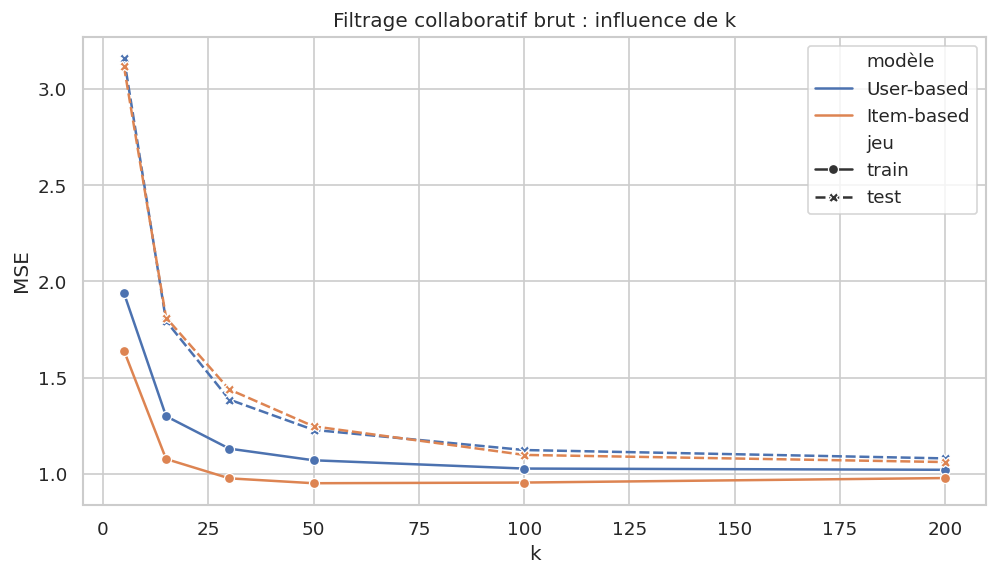

In [6]:
k_values = [5, 15, 30, 50, 100, 200]
raw_rows, raw_predictions = [], {}
ones_user = np.ones(user_similarity.shape[0], dtype=np.float32)
ones_item = np.ones(item_similarity.shape[0], dtype=np.float32)
for k in k_values:
    u_idx, u_w = precompute_topk(user_similarity, ones_user, k)
    i_idx, i_w = precompute_topk(item_similarity, ones_item, k)
    user_pred = predict_user_topk_matrix(train, train != 0, u_idx, u_w)
    item_pred = predict_item_topk_matrix(train, train != 0, i_idx, i_w)
    raw_predictions[k] = (user_pred, item_pred)
    raw_rows += [
        {"k": k, "modèle": "User-based", "jeu": "train", "MSE": mse_on_observed(user_pred, train)},
        {"k": k, "modèle": "User-based", "jeu": "test", "MSE": mse_on_observed(user_pred, test)},
        {"k": k, "modèle": "Item-based", "jeu": "train", "MSE": mse_on_observed(item_pred, train)},
        {"k": k, "modèle": "Item-based", "jeu": "test", "MSE": mse_on_observed(item_pred, test)},
    ]
raw_curve = pd.DataFrame(raw_rows)
display(raw_curve[raw_curve.jeu == "test"].pivot(index="k", columns="modèle", values="MSE"))
fig, ax = plt.subplots(figsize=(8.5, 5))
sns.lineplot(data=raw_curve, x="k", y="MSE", hue="modèle", style="jeu", markers=True, ax=ax)
ax.set_title("Filtrage collaboratif brut : influence de k")
fig.tight_layout(); fig.savefig(OUTPUT_DIR / "tp2_influence_k_brut.png", dpi=180)
plt.show()

**Réponse.** Un voisinage très petit est instable ; un voisinage trop large
dilue l'information avec des voisins peu pertinents. Le minimum sur la courbe
test est le compromis à retenir.

## 5. Débiaisage et combinaison débiaisage + top-k

modèle,Item-based centré,User-based centré
k,,
5,1.137890,1.224902
15,1.109905,1.151461
30,1.066711,1.065174
50,1.030987,1.007549
100,0.989676,0.969921
200,0.941588,0.948131


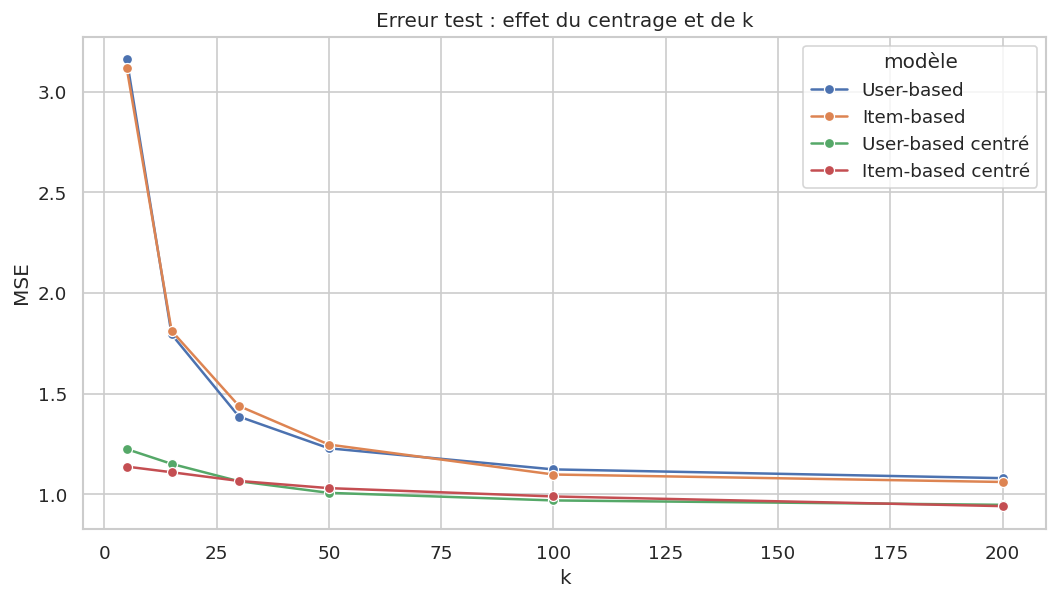

In [7]:
user_centered, user_means = center_observed(train, axis=1)
item_centered, item_means = center_observed(train, axis=0)
user_similarity_centered = fast_similarity(user_centered, kind="user")
item_similarity_centered = fast_similarity(item_centered, kind="item")
centered_rows, centered_predictions = [], {}
ones_user_c = np.ones(user_similarity_centered.shape[0], dtype=np.float32)
ones_item_c = np.ones(item_similarity_centered.shape[0], dtype=np.float32)
for k in k_values:
    u_idx, u_w = precompute_topk(user_similarity_centered, ones_user_c, k)
    i_idx, i_w = precompute_topk(item_similarity_centered, ones_item_c, k)
    user_pred = predict_user_topk_matrix(
        user_centered, train != 0, u_idx, u_w, baselines=user_means)
    item_pred = predict_item_topk_matrix(
        item_centered, train != 0, i_idx, i_w) + item_means[None, :]
    centered_predictions[k] = (user_pred, item_pred)
    centered_rows += [
        {"k": k, "modèle": "User-based centré", "jeu": "train", "MSE": mse_on_observed(user_pred, train)},
        {"k": k, "modèle": "User-based centré", "jeu": "test", "MSE": mse_on_observed(user_pred, test)},
        {"k": k, "modèle": "Item-based centré", "jeu": "train", "MSE": mse_on_observed(item_pred, train)},
        {"k": k, "modèle": "Item-based centré", "jeu": "test", "MSE": mse_on_observed(item_pred, test)},
    ]
centered_curve = pd.DataFrame(centered_rows)
display(centered_curve[centered_curve.jeu == "test"].pivot(index="k", columns="modèle", values="MSE"))
combined_test = pd.concat([
    raw_curve[raw_curve.jeu == "test"], centered_curve[centered_curve.jeu == "test"]
], ignore_index=True)
fig, ax = plt.subplots(figsize=(9, 5.2))
sns.lineplot(data=combined_test, x="k", y="MSE", hue="modèle", marker="o", ax=ax)
ax.set_title("Erreur test : effet du centrage et de k")
fig.tight_layout(); fig.savefig(OUTPUT_DIR / "tp2_comparaison_k_debiaisage.png", dpi=180)
plt.show()

**Réponse.** Le centrage est calculé uniquement sur les notes observées. Il
distingue la préférence relative du niveau de sévérité de chaque utilisateur.
La combinaison centrage + top-k est plus solide que les variantes naïves.

## 6. Films similaires : cosinus puis Pearson

In [8]:
movie_examples = {0: "Toy Story", 1: "GoldenEye", 20: "Muppet Treasure Island"}
cosine_lists = {
    label: top_k_movies(item_similarity, title_by_idx, idx, 6)
    for idx, label in movie_examples.items()
}
print("Voisins selon le cosinus :")
for label, values in cosine_lists.items():
    print()
    print(label, ":")
    for value in values:
        print(" -", value)

item_correlation = pearson_item_similarity(train)
pearson_lists = {
    label: top_k_movies(item_correlation, title_by_idx, idx, 6)
    for idx, label in movie_examples.items()
}
print()
print("Voisins selon Pearson :")
for label, values in pearson_lists.items():
    print()
    print(label, ":")
    for value in values:
        print(" -", value)

Voisins selon le cosinus :

Toy Story :
 - Star Wars (1977)
 - Return of the Jedi (1983)
 - Independence Day (ID4) (1996)
 - Mission: Impossible (1996)
 - Raiders of the Lost Ark (1981)
 - Rock, The (1996)

GoldenEye :
 - Under Siege (1992)
 - True Lies (1994)
 - Top Gun (1986)
 - Batman (1989)
 - Die Hard: With a Vengeance (1995)
 - Cliffhanger (1993)

Muppet Treasure Island :
 - Naked Gun 33 1/3: The Final Insult (1994)
 - Aladdin (1992)
 - Sgt. Bilko (1996)
 - Hot Shots! Part Deux (1993)
 - Sound of Music, The (1965)
 - Stargate (1994)

Voisins selon Pearson :

Toy Story :
 - Aladdin (1992)
 - Mission: Impossible (1996)
 - Star Wars (1977)
 - Independence Day (ID4) (1996)
 - Beauty and the Beast (1991)
 - Willy Wonka and the Chocolate Factory (1971)

GoldenEye :
 - Under Siege (1992)
 - True Lies (1994)
 - Cliffhanger (1993)
 - Top Gun (1986)
 - Die Hard: With a Vengeance (1995)
 - Stargate (1994)

Muppet Treasure Island :
 - Naked Gun 33 1/3: The Final Insult (1994)
 - Sgt. Bilko (

**Réponse.** Le cosinus brut est influencé par la popularité. Pearson centre les
profils et insiste sur les variations communes. Les listes ne coïncident donc
que partiellement. Une proximité statistique ne garantit pas une proximité de
genre ou de scénario.

In [9]:
raw_test = raw_curve[raw_curve.jeu == "test"].copy()
centered_test = centered_curve[centered_curve.jeu == "test"].copy()
raw_best = raw_test.loc[raw_test.MSE.idxmin()].to_dict()
centered_best = centered_test.loc[centered_test.MSE.idxmin()].to_dict()
metrics_tp2 = {
    "dataset": {"ratings": int(len(ratings_df)), "users": int(ratings.shape[0]), "items": int(ratings.shape[1]), "density_pct": float(density_pct)},
    "nearest_user_to_user_1": {"user_id": int(nearest_user_idx+1), "cosine": float(user_one_scores[nearest_user_idx])},
    "simple": simple_metrics.to_dict(orient="records"),
    "raw_curve_test": raw_test.to_dict(orient="records"),
    "centered_curve_test": centered_test.to_dict(orient="records"),
    "best_raw": {"k": int(raw_best["k"]), "model": raw_best["modèle"], "mse": float(raw_best["MSE"])},
    "best_centered": {"k": int(centered_best["k"]), "model": centered_best["modèle"], "mse": float(centered_best["MSE"])},
    "cosine_neighbors": cosine_lists,
    "pearson_neighbors": pearson_lists,
}
(OUTPUT_DIR / "metrics_tp2.json").write_text(
    json.dumps(metrics_tp2, indent=2, ensure_ascii=False), encoding="utf-8")
print("Meilleur brut   :", metrics_tp2["best_raw"])
print("Meilleur centré :", metrics_tp2["best_centered"])

Meilleur brut   : {'k': 200, 'model': 'Item-based', 'mse': 1.0615427494049072}
Meilleur centré : {'k': 200, 'model': 'Item-based centré', 'mse': 0.941587507724762}


## Conclusion TP2

La matrice est très creuse, les opérations matricielles rendent les calculs
réalistes, $k$ doit être validé, et le débiaisage sur les seules notes observées
améliore l'interprétation. Cosinus et Pearson représentent deux notions de
proximité différentes.